# Traffic Demand Prediction - Exploratory Data Analysis (EDA)

This notebook provides a thorough Exploratory Data Analysis (EDA) for the Traffic Demand Prediction task.
It loads the dataset, inspects missing values, analyzes the target variable (`demand`), visualizes individual features, runs correlation analyses, explores time patterns, and summarizes key insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# Load datasets
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

print(f'Train dataset shape: {train_df.shape}')
print(f'Test dataset shape: {test_df.shape}')
print('\nTrain columns:', list(train_df.columns))
print('Test columns:', list(test_df.columns))

Train dataset shape: (77299, 11)
Test dataset shape: (41778, 10)

Train columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']
Test columns: ['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


In [3]:
print('--- Train Data Sample ---')
display(train_df.head())

print('--- Data Types & Non-Null Counts ---')
train_df.info()

--- Train Data Sample ---


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


## 2. Check for Missing Values

We identify missing values in both the training and test datasets.

In [4]:
train_missing = train_df.isnull().sum()
train_missing_pct = 100 * train_df.isnull().mean()
missing_train_df = pd.DataFrame({'Missing Count': train_missing, 'Percentage (%)': train_missing_pct})
print('--- Missing values in Train Data ---')
display(missing_train_df[missing_train_df['Missing Count'] > 0])

test_missing = test_df.isnull().sum()
test_missing_pct = 100 * test_df.isnull().mean()
missing_test_df = pd.DataFrame({'Missing Count': test_missing, 'Percentage (%)': test_missing_pct})
print('--- Missing values in Test Data ---')
display(missing_test_df[missing_test_df['Missing Count'] > 0])

--- Missing values in Train Data ---


,Missing Count,Percentage (%)
RoadType,600,0.776207
Temperature,2495,3.227726
Weather,797,1.031061


--- Missing values in Test Data ---


,Missing Count,Percentage (%)
RoadType,324,0.775528
Temperature,1349,3.228972
Weather,431,1.031643


## 3. Understand the Target Variable (`demand`)

We compute key statistics of the `demand` column and evaluate its skewness to decide if a log transformation is appropriate.

In [5]:
print('Summary Statistics of demand:')
display(train_df['demand'].describe())
print(f'Median: {train_df["demand"].median()}')
print(f'Skewness: {train_df["demand"].skew()}')
print(f'Minimum value (non-zero check): {train_df["demand"].min()}')

Summary Statistics of demand:


count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

Median: 0.0477599362718394
Skewness: 3.7285172887316613
Minimum value (non-zero check): 6.245650130093708e-07


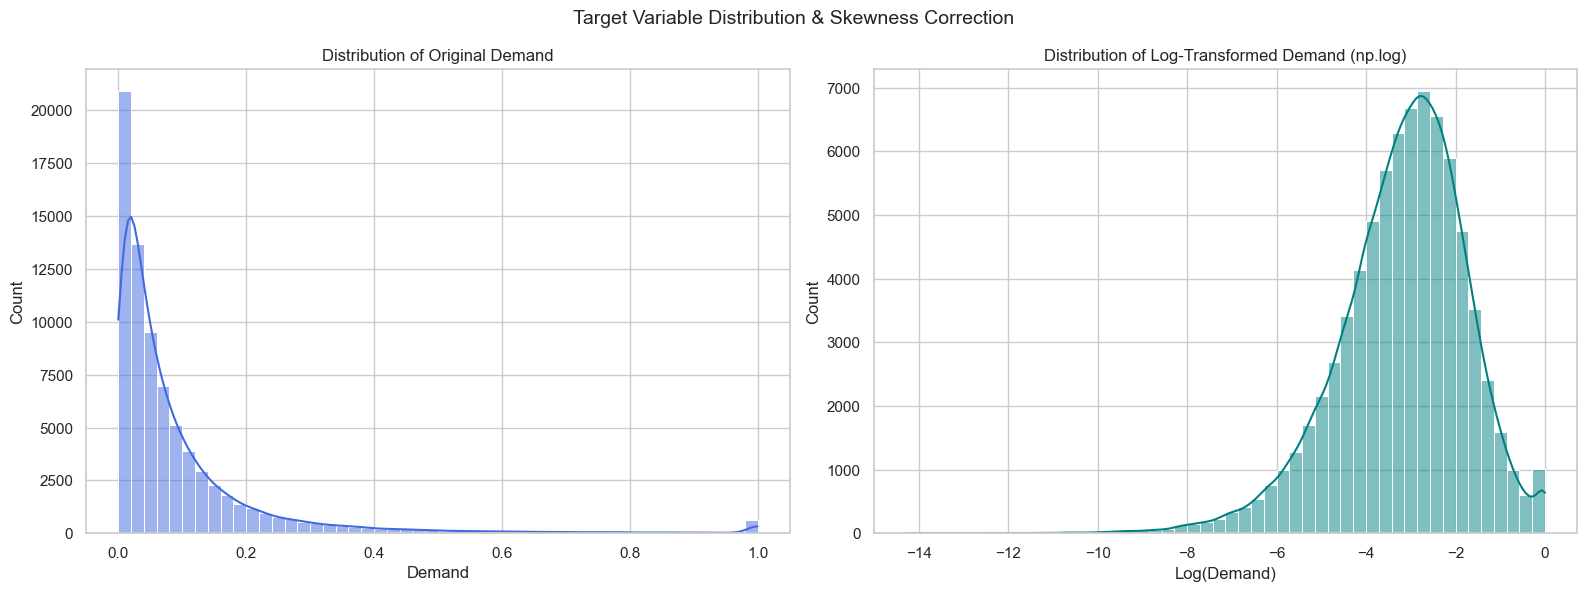

Original skewness: 3.7285
Log-transformed skewness: -0.7276


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original distribution
sns.histplot(train_df['demand'], kde=True, bins=50, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Original Demand')
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')

# Log distribution
log_demand = np.log(train_df['demand'])
sns.histplot(log_demand, kde=True, bins=50, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Log-Transformed Demand (np.log)')
axes[1].set_xlabel('Log(Demand)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Distribution & Skewness Correction', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Original skewness: {train_df["demand"].skew():.4f}')
print(f'Log-transformed skewness: {log_demand.skew():.4f}')

## 4. Analyze Each Feature

We break down the categorical features (`RoadType`, `Weather`, `LargeVehicles`, `Landmarks`), numerical features (`Temperature`, `NumberofLanes`), and geographical identifiers (`geohash`).

### Categorical Columns: Value Counts & Bar Charts

--- Column: RoadType ---
Unique counts (including NaNs):
RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

--- Column: Weather ---
Unique counts (including NaNs):
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64

--- Column: LargeVehicles ---
Unique counts (including NaNs):
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

--- Column: Landmarks ---
Unique counts (including NaNs):
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64



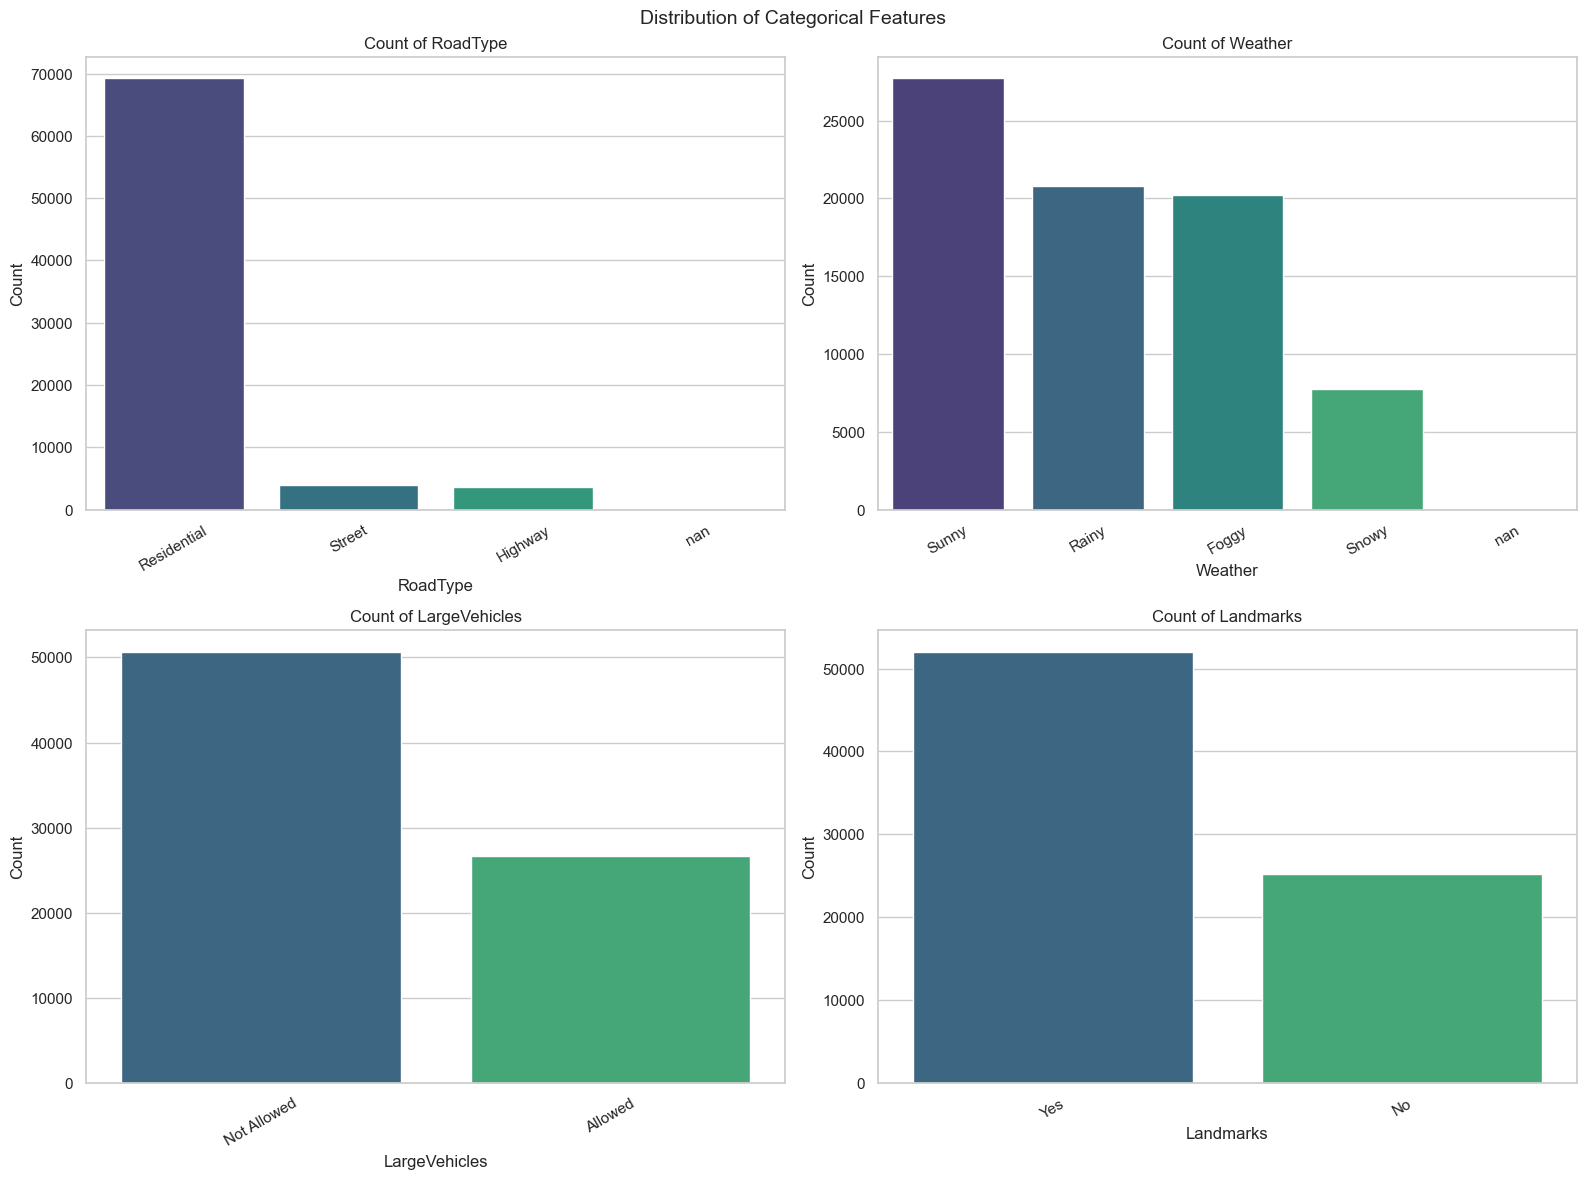

In [7]:
cat_cols = ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']

for col in cat_cols:
    print(f'--- Column: {col} ---')
    print('Unique counts (including NaNs):')
    print(train_df[col].value_counts(dropna=False))
    print() 

# Plot value counts for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=train_df, x=col, ax=axes[i], order=train_df[col].value_counts(dropna=False).index, palette='viridis')
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribution of Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

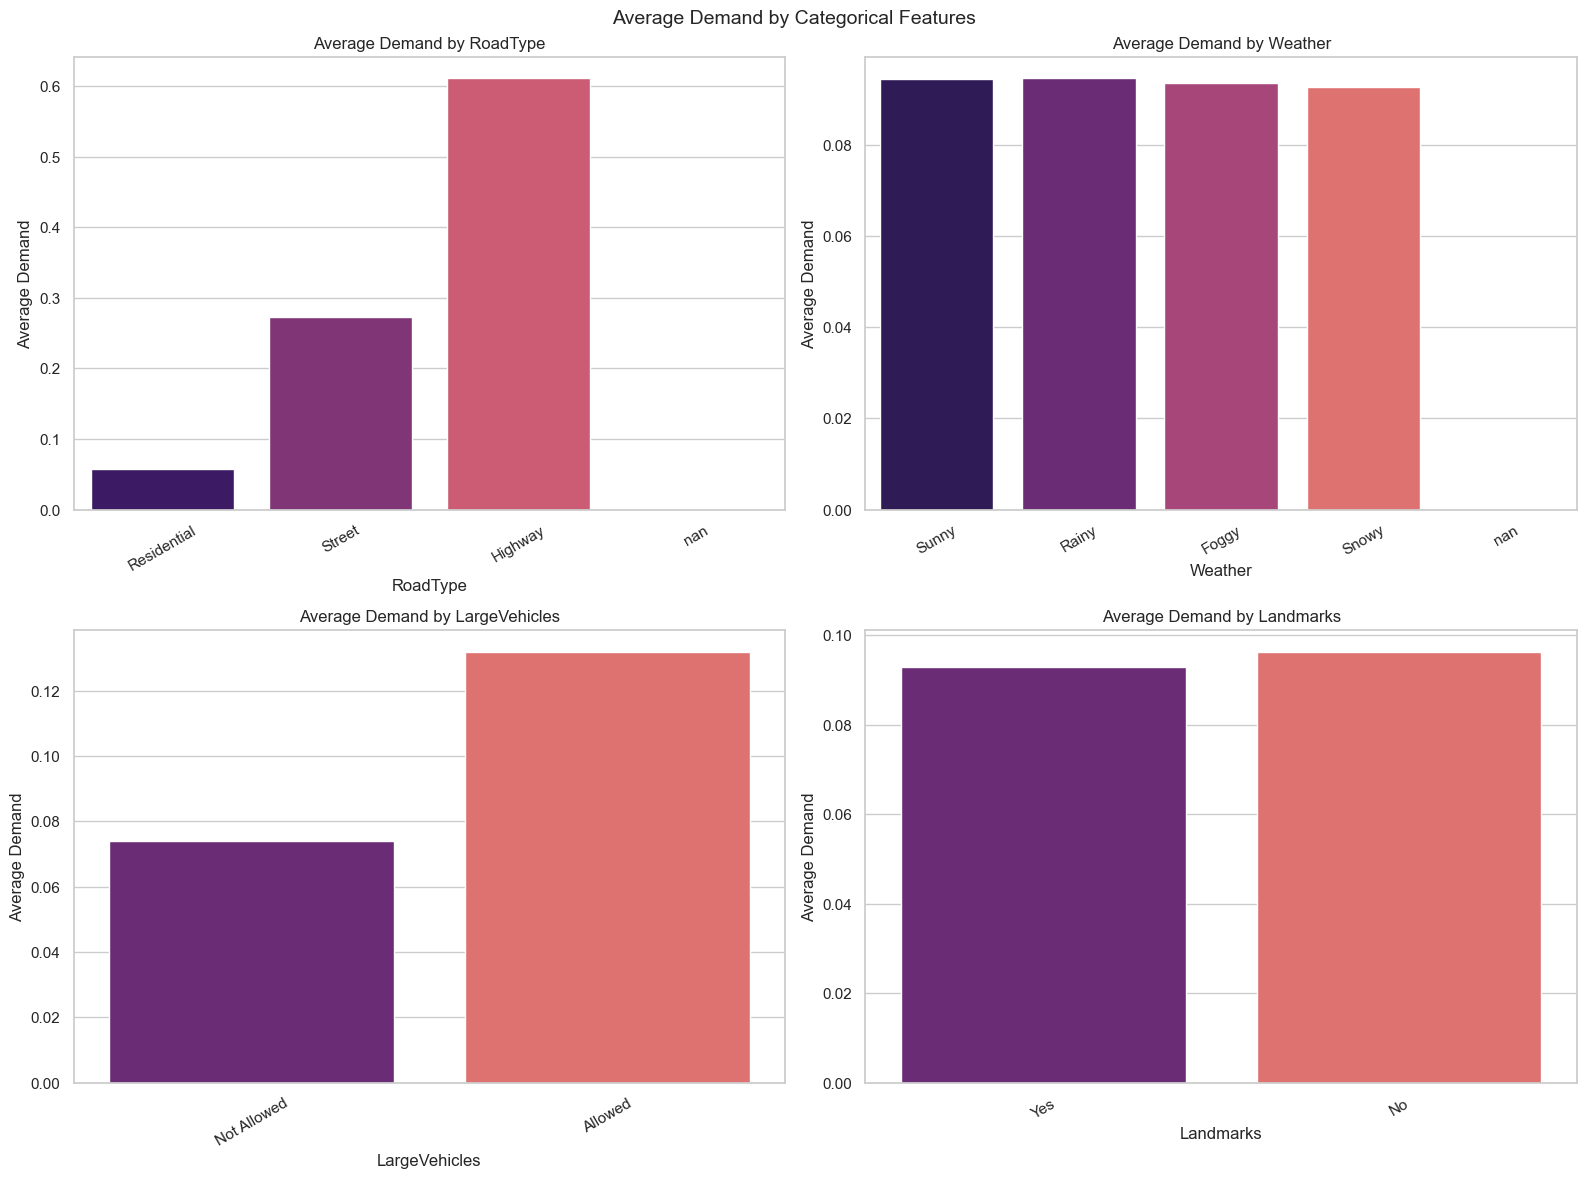

In [8]:
# Plot average demand per category to understand relationships
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.barplot(data=train_df, x=col, y='demand', ax=axes[i], order=train_df[col].value_counts(dropna=False).index, palette='magma', errorbar=None)
    axes[i].set_title(f'Average Demand by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Average Demand')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Average Demand by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Numerical Columns: Distributions & Box Plots

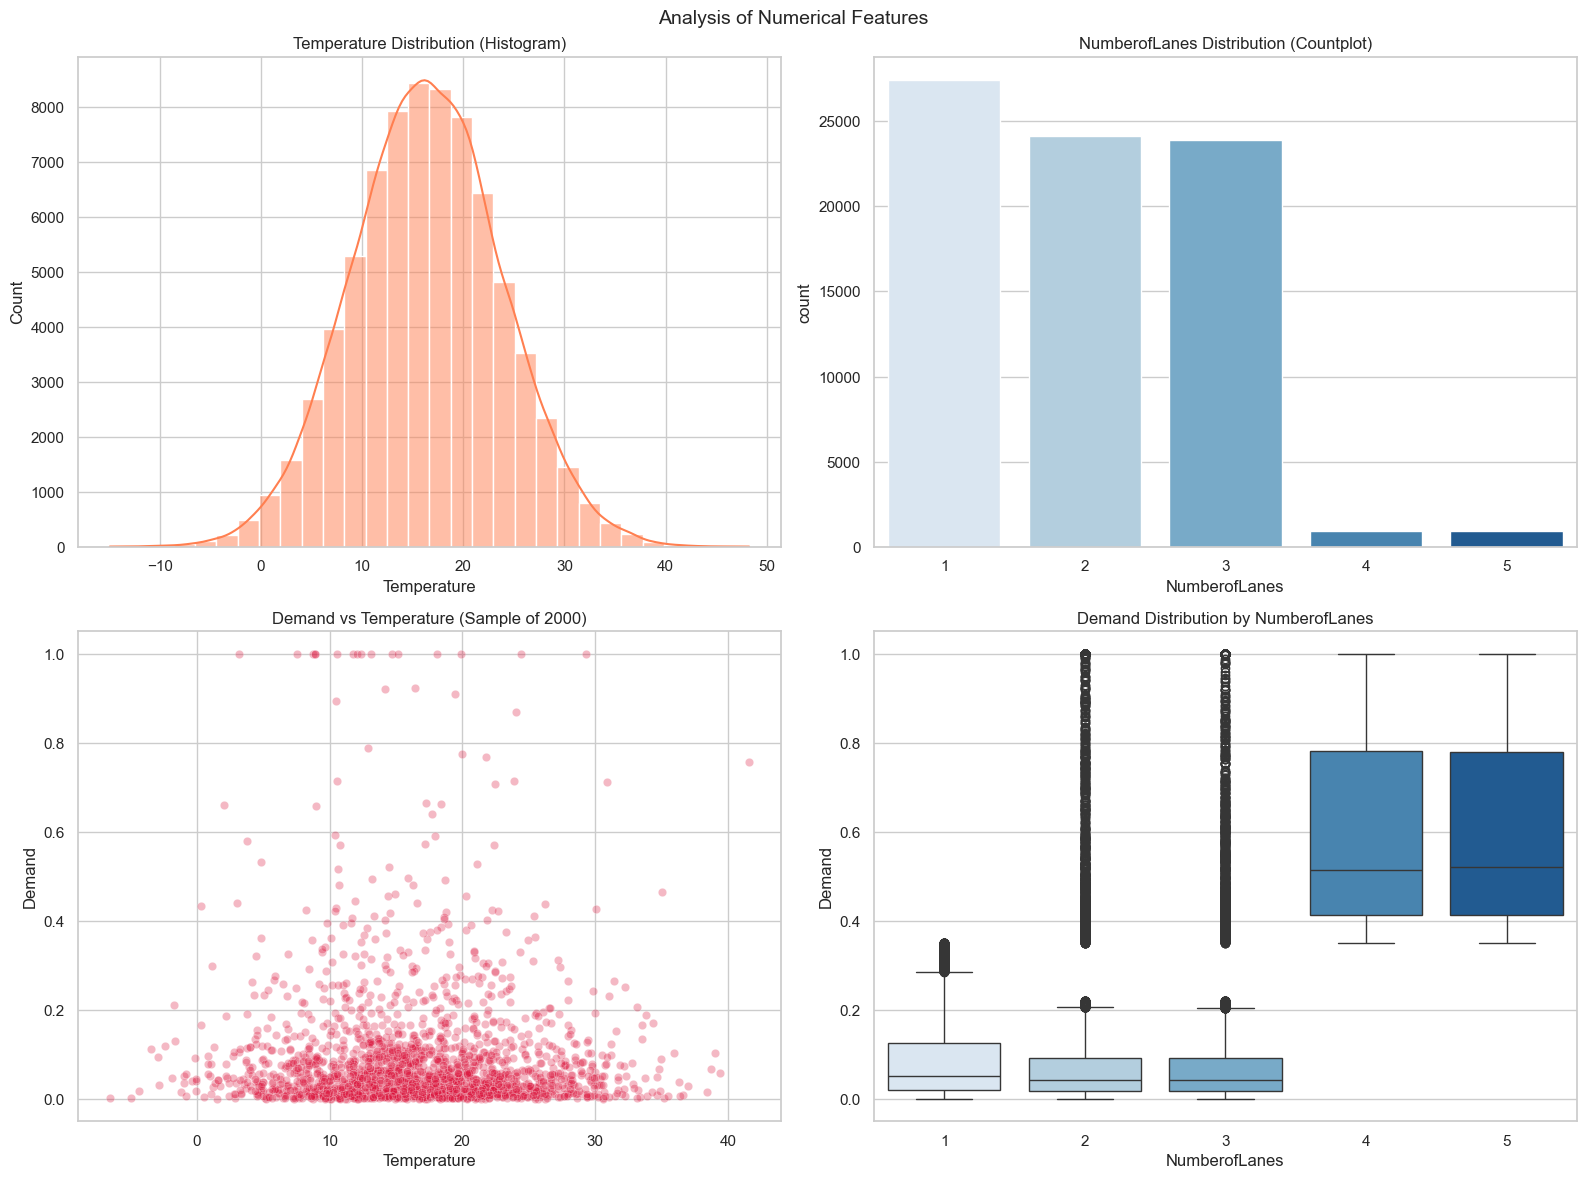

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Temperature Histogram
sns.histplot(train_df['Temperature'].dropna(), kde=True, ax=axes[0, 0], color='coral', bins=30)
axes[0, 0].set_title('Temperature Distribution (Histogram)')
axes[0, 0].set_xlabel('Temperature')

# NumberofLanes Countplot
sns.countplot(data=train_df, x='NumberofLanes', ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('NumberofLanes Distribution (Countplot)')
axes[0, 1].set_xlabel('NumberofLanes')

# Temperature vs Demand
sns.scatterplot(data=train_df.sample(2000, random_state=42), x='Temperature', y='demand', alpha=0.3, ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Demand vs Temperature (Sample of 2000)')
axes[1, 0].set_xlabel('Temperature')
axes[1, 0].set_ylabel('Demand')

# NumberofLanes vs Demand Boxplot
sns.boxplot(data=train_df, x='NumberofLanes', y='demand', ax=axes[1, 1], palette='Blues')
axes[1, 1].set_title('Demand Distribution by NumberofLanes')
axes[1, 1].set_xlabel('NumberofLanes')
axes[1, 1].set_ylabel('Demand')

plt.suptitle('Analysis of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Geohash Locations Analysis

Number of unique geohashes in Train: 1249
Number of unique geohashes in Test: 1190
Geohash overlap between Train & Test: 1180
Geohashes in Test but not in Train: 10

--- Top 10 Busiest Locations (by total demand sum) ---
geohash
qp09d9    100.875051
qp09ft     91.229263
qp09e5     90.823835
qp09d8     70.278428
qp096x     69.891173
qp09d2     69.795790
qp09dc     69.453521
qp096r     68.299160
qp09d3     67.567286
qp03xx     66.275346
Name: demand, dtype: float64


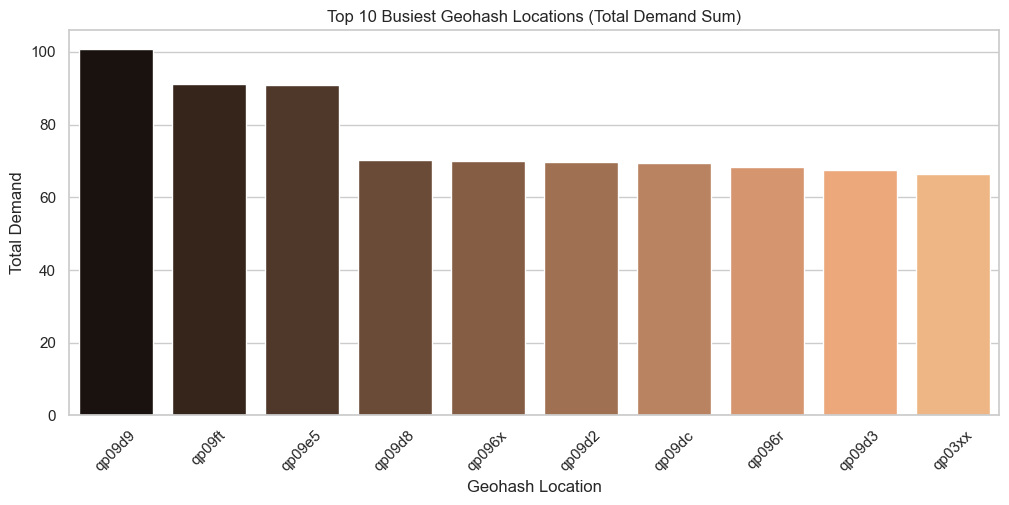

In [10]:
print(f'Number of unique geohashes in Train: {train_df["geohash"].nunique()}')
print(f'Number of unique geohashes in Test: {test_df["geohash"].nunique()}')

train_geos = set(train_df['geohash'])
test_geos = set(test_df['geohash'])
overlap = train_geos.intersection(test_geos)
print(f'Geohash overlap between Train & Test: {len(overlap)}')
print(f'Geohashes in Test but not in Train: {len(test_geos - train_geos)}')

# Top 10 busiest locations (highest total demand)
top_10_demand = train_df.groupby('geohash')['demand'].sum().sort_values(ascending=False).head(10)
print("\n--- Top 10 Busiest Locations (by total demand sum) ---")
print(top_10_demand)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_10_demand.index, y=top_10_demand.values, palette='copper')
plt.title('Top 10 Busiest Geohash Locations (Total Demand Sum)')
plt.xlabel('Geohash Location')
plt.ylabel('Total Demand')
plt.xticks(rotation=45)
plt.show()

## 5. Correlation Analysis

We map the categorical variables to numeric codes to investigate linear correlations with `demand`.

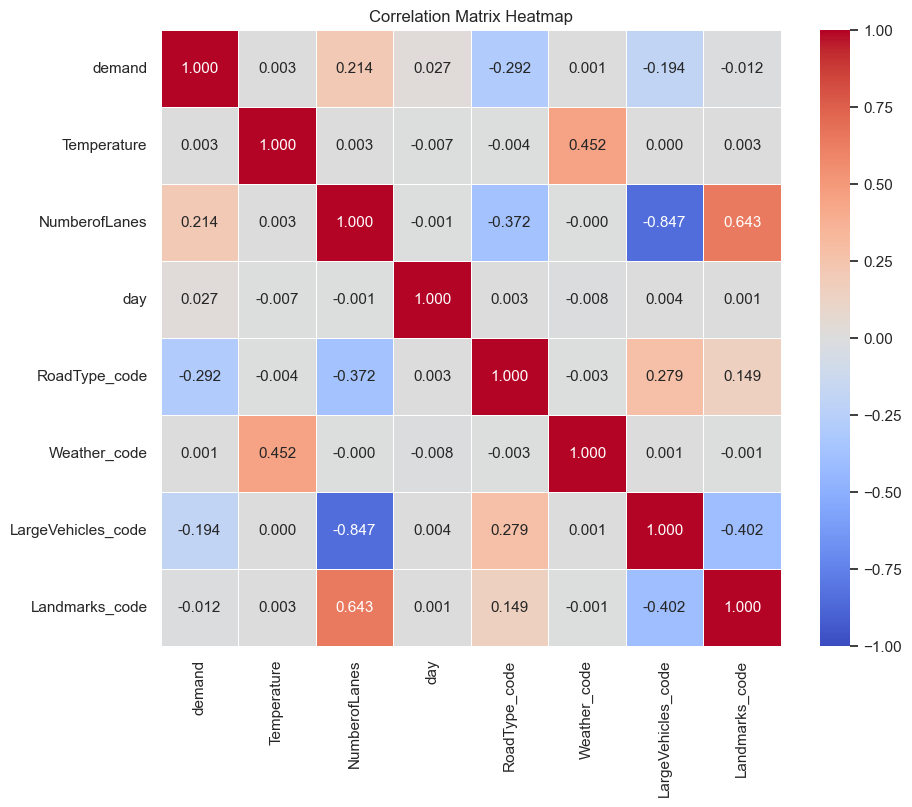

Correlation of features with demand (sorted):
demand                1.000000
NumberofLanes         0.214148
day                   0.026807
Temperature           0.003144
Weather_code          0.000929
Landmarks_code       -0.011527
LargeVehicles_code   -0.193623
RoadType_code        -0.291553
Name: demand, dtype: float64


In [11]:
corr_df = train_df.copy()
corr_df['RoadType_code'] = corr_df['RoadType'].astype('category').cat.codes
corr_df['Weather_code'] = corr_df['Weather'].astype('category').cat.codes
corr_df['LargeVehicles_code'] = corr_df['LargeVehicles'].astype('category').cat.codes
corr_df['Landmarks_code'] = corr_df['Landmarks'].astype('category').cat.codes

features_for_corr = ['demand', 'Temperature', 'NumberofLanes', 'day', 
                     'RoadType_code', 'Weather_code', 'LargeVehicles_code', 'Landmarks_code']

corr_matrix = corr_df[features_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

print('Correlation of features with demand (sorted):')
print(corr_matrix['demand'].sort_values(ascending=False))

## 6. Time Patterns

We parse `timestamp` to study how traffic demand fluctuates by day and hour.

Average demand by Day:


day
48    0.092659
49    0.105262
Name: demand, dtype: float64


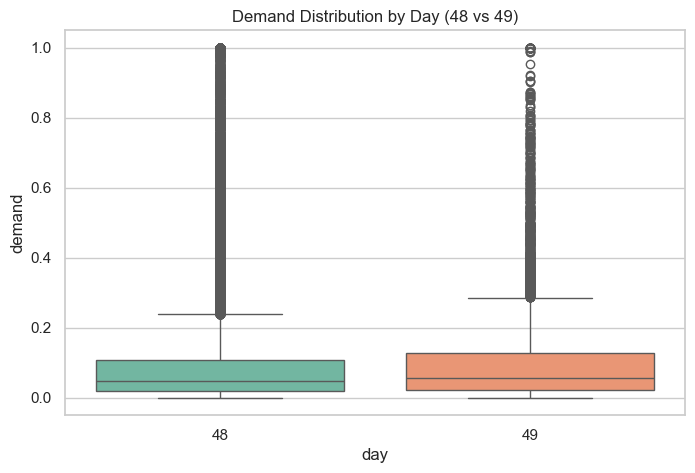

In [12]:
# Parse timestamp
def parse_time(df):
    df_copy = df.copy()
    time_split = df_copy['timestamp'].str.split(':', expand=True)
    df_copy['Hour'] = time_split[0].astype(int)
    df_copy['Minute'] = time_split[1].astype(int)
    df_copy['TimeInMinutes'] = df_copy['Hour'] * 60 + df_copy['Minute']
    return df_copy

train_time = parse_time(train_df)

print('Average demand by Day:')
print(train_time.groupby('day')['demand'].mean())

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_time, x='day', y='demand', palette='Set2')
plt.title('Demand Distribution by Day (48 vs 49)')
plt.show()

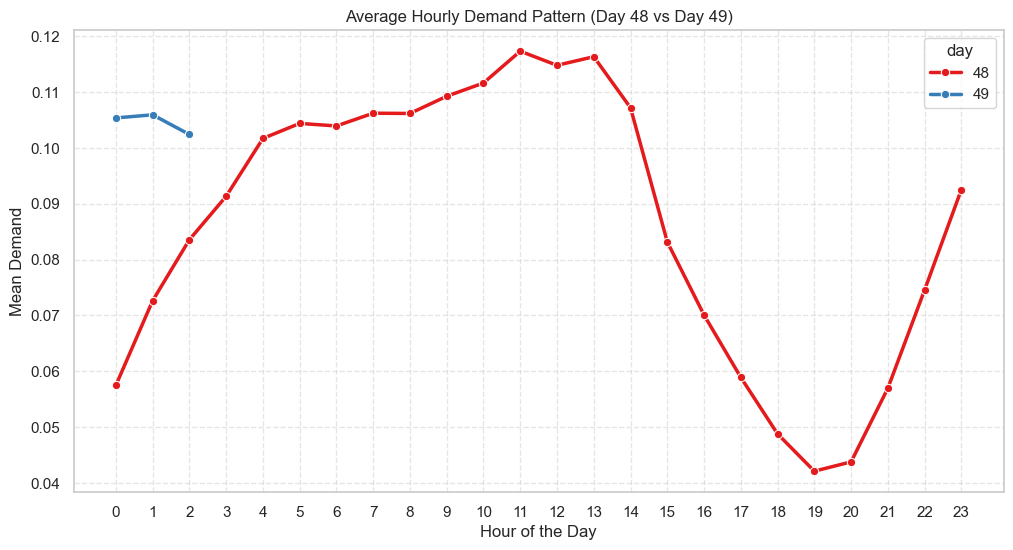

In [13]:
# Hourly demand trends per day
hourly_demand = train_time.groupby(['day', 'Hour'])['demand'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_demand, x='Hour', y='demand', hue='day', marker='o', palette='Set1', linewidth=2.5)
plt.title('Average Hourly Demand Pattern (Day 48 vs Day 49)')
plt.xlabel('Hour of the Day')
plt.ylabel('Mean Demand')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

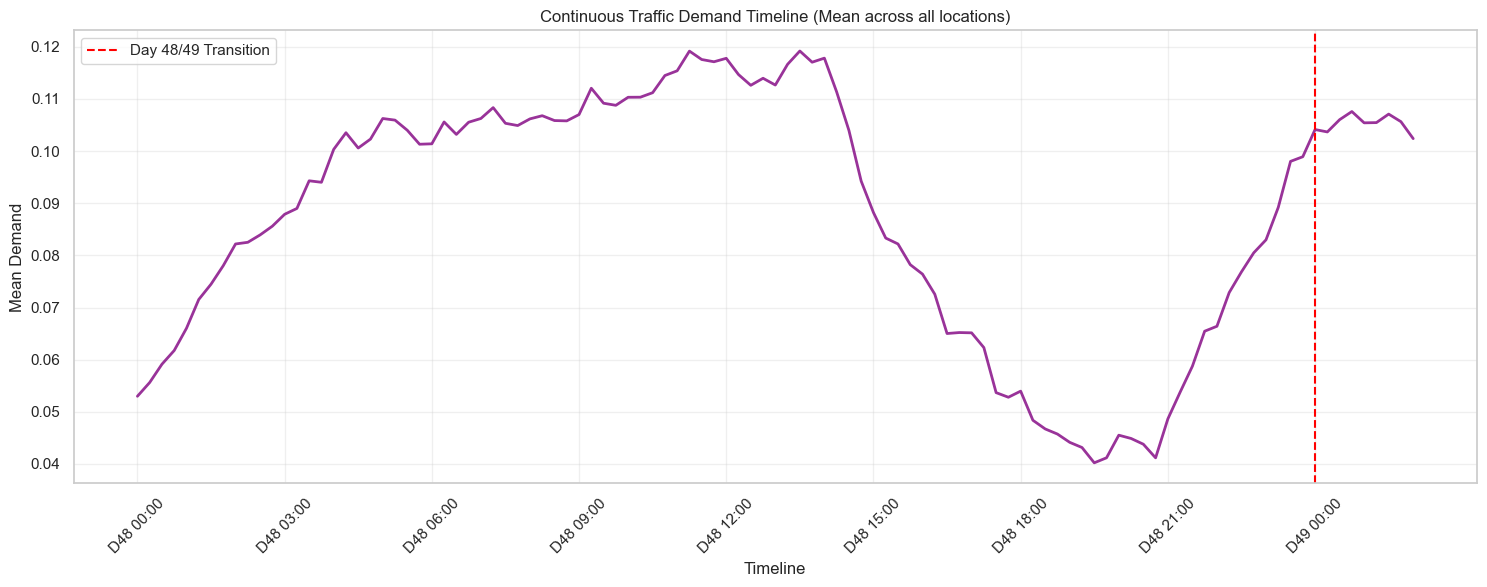

In [14]:
# Continuous demand timeline
train_time['TimelineMinutes'] = (train_time['day'] - 48) * 1440 + train_time['TimeInMinutes']
timeline_demand = train_time.groupby('TimelineMinutes')['demand'].mean().reset_index()

def get_label(min_val):
    d = 48 + min_val // 1440
    m = min_val % 1440
    h = m // 60
    mn = m % 60
    return f'D{d} {h:02d}:{mn:02d}'

plt.figure(figsize=(15, 6))
plt.plot(timeline_demand['TimelineMinutes'], timeline_demand['demand'], color='purple', alpha=0.8, linewidth=2)
plt.axvline(x=1440, color='red', linestyle='--', label='Day 48/49 Transition')
plt.title('Continuous Traffic Demand Timeline (Mean across all locations)')
plt.xlabel('Timeline')
plt.ylabel('Mean Demand')

ticks = np.arange(0, train_time['TimelineMinutes'].max() + 1, 180)
tick_labels = [get_label(t) for t in ticks]
plt.xticks(ticks, tick_labels, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Key Findings Summary

### Target Variable (`demand`)
* **Right-Skewed Distribution**: The demand variable is heavily right-skewed with a skewness of ~3.73. Most traffic observations represent low demand values (median of ~0.048 vs mean of ~0.094).
* **Log Transformation Benefit**: Applying a natural log transformation `np.log(demand)` results in a skewness of `-0.728`, which is much closer to normal, indicating log-transforming target might improve model accuracy.

### Missing Values
* Missing values are present in both the training and test sets in `RoadType` (~0.8% missing), `Temperature` (~3.2% missing), and `Weather` (~1.0% missing).

### Feature Analysis
* **RoadType**: `Residential` is the most common road type, but `Highway` road types exhibit higher average demand levels.
* **Weather**: `Sunny` weather has the highest frequency and average demand, while `Snowy` weather is associated with lower demand levels.
* **Large Vehicles & Landmarks**: Roads that allow large vehicles or have landmarks nearby see significantly higher average demand.
* **Number of Lanes**: High positive correlation with demand—more lanes correlate with higher traffic volume.

### Geohash Locations
* Out of 1,249 training geohashes and 1,190 test geohashes, 1,180 overlap. **10 geohashes are unique to the test set**, which will require robust location-level generalization.

### Time Patterns
* **Hourly Peaks**: Strong daily rhythm with two distinct peak periods: **08:00 - 10:00** (morning rush) and **16:00 - 19:00** (evening rush).
* **Low Demand Period**: Night hours from **00:00 to 05:00** see minimum traffic demand.